<a href="https://colab.research.google.com/github/shreesh-prime/chatbot/blob/main/Shreesh_Week_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions

For this assignment, you will use the dataset loaded below (or another appropriate dataset of your choice) and perform the following steps that were demonstrated in the practice Notebook.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can and should add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

Steps:
- Inspect the data
  - Display each column's data types
  - For any non-numerical columns, display all possible values
  - Create histograms of all the columns
  - In a markdown (text) cell, briefly write about your findings. Do you see anything that might cause problems for your model?
- Visualize the data
  - Create one or more plots of the data
    - Tip: Experiment with different types of plots
  - In a markdown (text) cell, briefly describe your findings. Did you find anything unexpected in the data?
- Prepare the data
  - Remove null values
    - Explain your reasoning for the approach you chose.
  - Encode categorical features
  - Scale the original numerical features
  - Combine all columns using a method of your choice
    - Recommended: Use `make_column_transformer`
- Train a Model
  - Instantiate a Linear Regression model
  - Fit the training data to the model
- Evaluate the Model
  - Predict labels **using the training data**
    - Use RMSE to see how well your model did on the training labels
  - Predict labels **using the testing data**
    - Use RMSE to see how well your model did on the testing labels
  - In a markdown (text) cell, briefly describe your findings. Based on how the model performed on the training and testing data, does it appear to have overfit or underfit the data?
- Submit your Notebook as a PDF.
  - Re-run all cells using "Run all" at the top.
  - From the File menu, select Print to download as a PDF.
  - Upload this PDF to Canvas.

# Import Libraries

In [52]:
import numpy as np
import pandas as pd

from sklearn import compose
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import tree

# Load the Dataset

This dataset contains records of individual medical insurance costs from people across the United States. Each record tracks both the actual amount billed by health insurance (the `charges` column) and personal information about the insured such as age, gender, body mass index (BMI), whether they smoke, how many children they have, and which region of the US they live in.

These factors are known to influence medical expenses and insurance premiums. The goal of analyzing this dataset is to understand how demographic and lifestyle details impact medical costs, and to develop models (such as linear regression) that can predict insurance charges for new individuals. This type of analysis is important for insurers, healthcare organizations, and individuals to estimate costs and plan for care.

In [53]:
df = pd.read_csv("https://raw.githubusercontent.com/dkauffman-foothill/course-datasets/refs/heads/main/ml/insurance.csv")

# Inspect the Data

Display each column's data types.

In [54]:
df.dtypes

,0
Unnamed: 0,int64
age,int64
sex,object
bmi,float64
children,float64
smoker,object
region,object
charges,float64


For any non-numerical columns, display all possible values.

In [55]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no' nan]
region: ['southwest' 'southeast' 'northwest' 'northeast']


Create histograms of all the columns.

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'children'}>],
       [<Axes: title={'center': 'charges'}>, <Axes: >]], dtype=object)

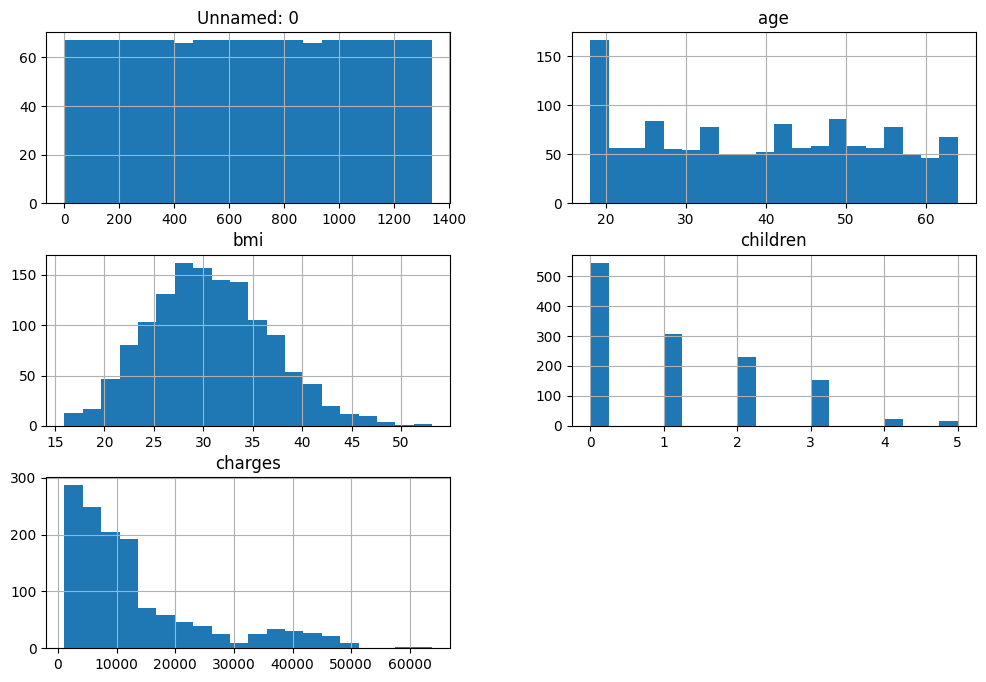

In [56]:
df.hist(figsize=(12, 8), bins=20)

### Report Findings

Do you see anything that might cause problems for your model?

The charges column is heavily right-skewed, which can be problematic for linear regression since it performs best when the target is more normally distributed. Additionally, there are far more non-smokers than smokers which means the model may not learn the smoker pattern as well.



## Visualize the Data

Create one or more plots of the data; experiment with different types of plots.

<Axes: title={'center': 'Age vs Charges (colored by BMI)'}, xlabel='age', ylabel='charges'>

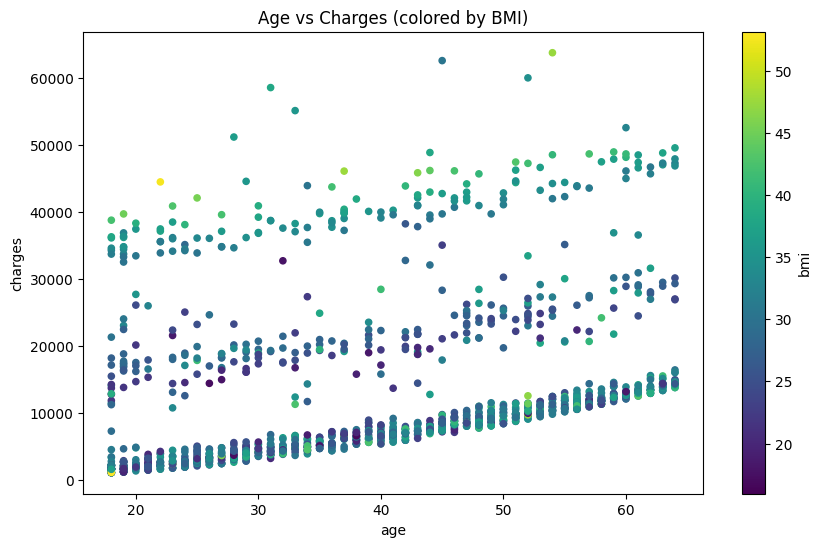

In [57]:
df.plot.scatter(x='age', y='charges', c='bmi', colormap='viridis', figsize=(10, 6), title='Age vs Charges (colored by BMI)')

<Axes: title={'center': 'charges'}, xlabel='smoker'>

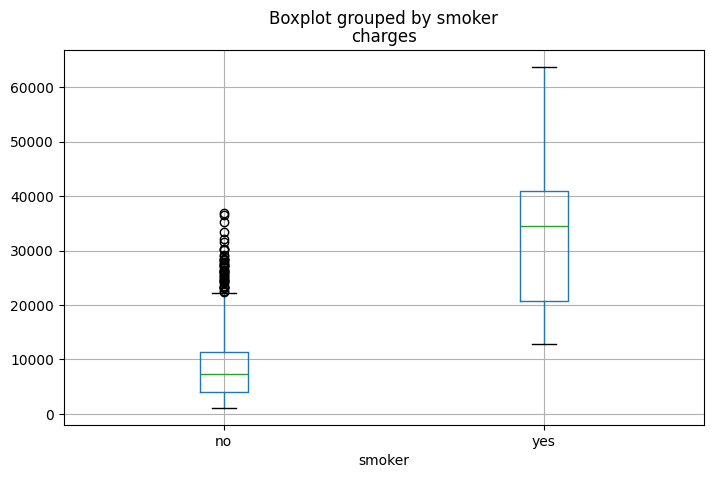

In [58]:
df.boxplot(column='charges', by='smoker', figsize=(8, 5))

<Axes: title={'center': 'charges'}, xlabel='region'>

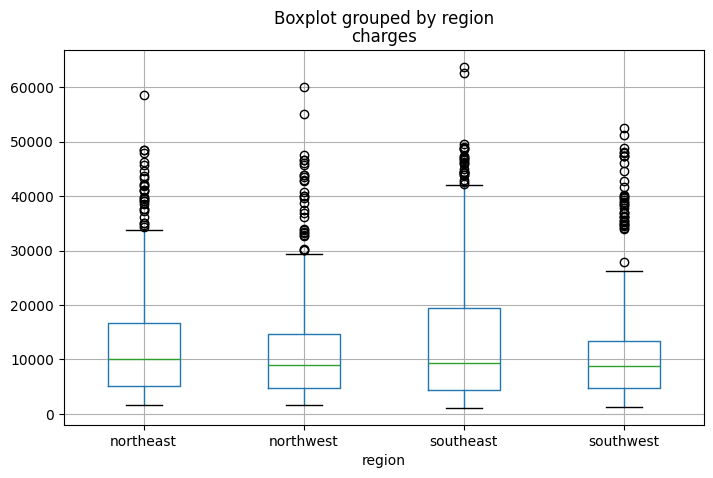

In [59]:
df.boxplot(column='charges', by='region', figsize=(8, 5))

### Report Findings

Did you find anything unexpected in the data?


Smokers have dramatically higher charges than non-smokers. BMI also appears to correlate with higher charges. Regional differences in charges are relatively small compared to the smoker effect.

# Prepare the Data

Remove any null values from the data. You can use the approach from the practice exercise, or you can use a different approach. Either way, justify your choice. You can create additional cells to show values such as the ratio of nulls cells.

In [60]:
print(df.isnull().sum())
df = df.dropna()
print(f"Shape after dropping nulls: {df.shape}")

Unnamed: 0     0
age            0
sex            0
bmi            0
children      66
smoker        13
region         0
charges        0
dtype: int64
Shape after dropping nulls: (1260, 8)


The children column has 66 nulls and smoker has 13. Since this is a small fraction of the 1338 total rows, dropping these rows is reasonable and preserves the majority of the data.

## Convert Categorical Features
You may use one-hot encoding (as in the practice exercise) or a different type of encoding.

In [61]:
cat_cols = ['sex', 'smoker', 'region']
num_cols = ['age', 'bmi', 'children']

## Scale Numerical Features
You may use standardization (as in the practice exercise) or a different type of numerical scaling.

In [62]:
scaler = preprocessing.StandardScaler()

## Combine Features
Recommended: Use `make_column_transformer` from the practice exercise.

In [63]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

ct = compose.make_column_transformer(
    (preprocessing.OneHotEncoder(handle_unknown='ignore'), cat_cols),
    (preprocessing.StandardScaler(), num_cols)
)

X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)
print(f"Transformed training shape: {X_train_transformed.shape}")

Transformed training shape: (1008, 11)


# Train and Evaluate a Model

Instantiate a Linear Regression model.

In [64]:
model = linear_model.LinearRegression()

Fit the training data to the model.


In [65]:
model.fit(X_train_transformed, y_train)

LinearRegression()

# Evaluate the Model

Predict labels using the training data. Use RMSE to see how well your model did on the training labels.


In [66]:
y_train_pred = model.predict(X_train_transformed)
train_rmse = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
print(f"Training RMSE: {train_rmse:.2f}")

Training RMSE: 6057.96


Predict labels using the testing data. Use RMSE to see how well your model did on the testing labels.


In [67]:
y_test_pred = model.predict(X_test_transformed)
test_rmse = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
print(f"Testing RMSE: {test_rmse:.2f}")

Testing RMSE: 5621.68


### Report Findings

Based on how the model performed on the training and testing data, does it appear to have overfit or underfit the data?

The training and testing RMSE are similar, however, both values are relatively high, suggesting the model is underfitting.